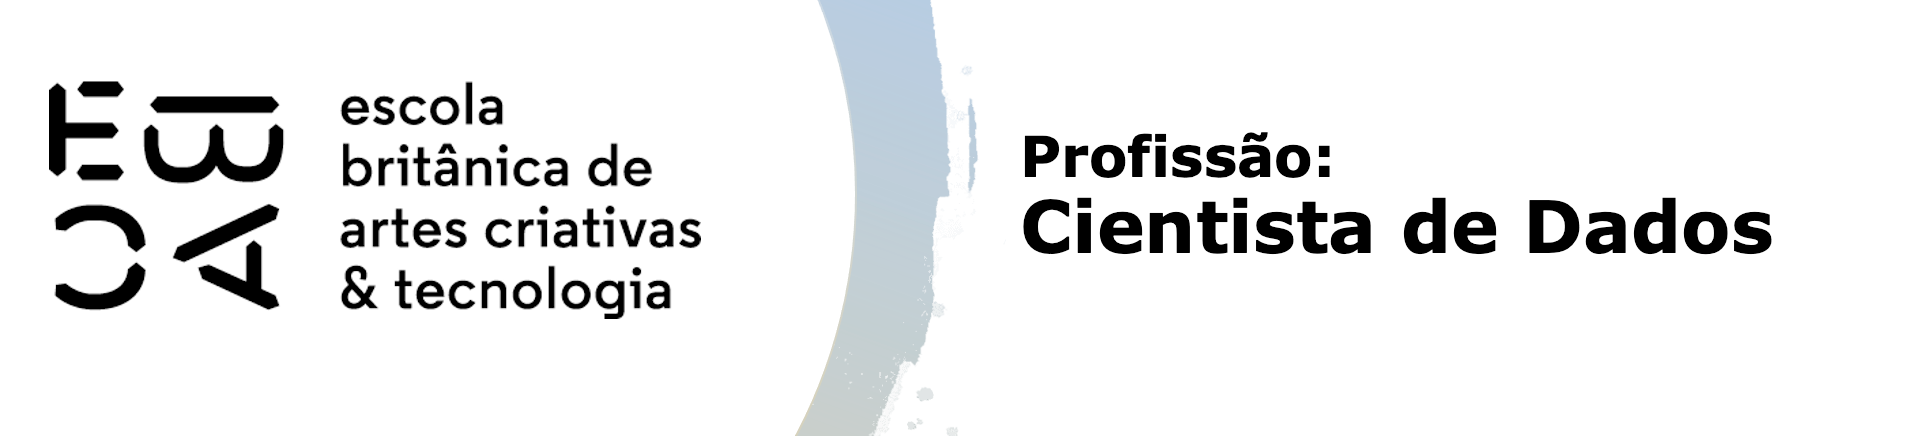

# Tarefa II

Neste projeto, estamos construindo um credit scoring para cartão de crédito, em um desenho amostral com 15 safras, e utilizando 12 meses de performance.

Carregue a base de dados ```credit_scoring.ftr```.

In [19]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_feather('credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


## Amostragem

Separe os três últimos meses como safras de validação *out of time* (oot).

Variáveis:<br>
Considere que a variável ```data_ref``` não é uma variável explicativa, é somente uma variável indicadora da safra, e não deve ser utilizada na modelagem. A variávei ```index``` é um identificador do cliente, e também não deve ser utilizada como covariável (variável explicativa). As restantes podem ser utilizadas para prever a inadimplência, incluindo a renda.


In [20]:
# Garantir que data_ref está em datetime
df['data_ref'] = pd.to_datetime(df['data_ref'])

# Criar a "safra" como mês
df['safra_mes'] = df['data_ref'].dt.to_period('M').dt.to_timestamp()

# Listar as 3 últimas safras
ultimas_3_safras = sorted(df['safra_mes'].unique())[-3:]
ultimas_3_safras


[Timestamp('2016-01-01 00:00:00'),
 Timestamp('2016-02-01 00:00:00'),
 Timestamp('2016-03-01 00:00:00')]

In [21]:
# OOT = últimas 3 safras
df_oot = df[df['safra_mes'].isin(ultimas_3_safras)].copy()

# Treino/desenvolvimento = todo o resto
df_treino = df[~df['safra_mes'].isin(ultimas_3_safras)].copy()

print("Safras OOT:", ultimas_3_safras)
print("Linhas treino:", df_treino.shape[0])
print("Linhas OOT:", df_oot.shape[0])


Safras OOT: [Timestamp('2016-01-01 00:00:00'), Timestamp('2016-02-01 00:00:00'), Timestamp('2016-03-01 00:00:00')]
Linhas treino: 600000
Linhas OOT: 150000


In [22]:
print("Treino - intervalo de datas:", df_treino['data_ref'].min(), "até", df_treino['data_ref'].max())
print("OOT    - intervalo de datas:", df_oot['data_ref'].min(), "até", df_oot['data_ref'].max())

# Quantidade por safra (para confirmar)
display(df_treino['safra_mes'].value_counts().sort_index())
display(df_oot['safra_mes'].value_counts().sort_index())


Treino - intervalo de datas: 2015-01-01 00:00:00 até 2015-12-01 00:00:00
OOT    - intervalo de datas: 2016-01-01 00:00:00 até 2016-03-01 00:00:00


safra_mes
2015-01-01    50000
2015-02-01    50000
2015-03-01    50000
2015-04-01    50000
2015-05-01    50000
2015-06-01    50000
2015-07-01    50000
2015-08-01    50000
2015-09-01    50000
2015-10-01    50000
2015-11-01    50000
2015-12-01    50000
Name: count, dtype: int64

safra_mes
2016-01-01    50000
2016-02-01    50000
2016-03-01    50000
Name: count, dtype: int64

## Descritiva básica univariada

- Descreva a base quanto ao número de linhas, número de linhas para cada mês em ```data_ref```.
- Faça uma descritiva básica univariada de cada variável. Considere as naturezas diferentes: qualitativas e quantitativas.

In [23]:
print(f"Número total de observações: {df.shape[0]}")
print(f"Número total de variáveis: {df.shape[1]}")

Número total de observações: 750000
Número total de variáveis: 16


In [24]:
# Criar variável mensal
df['mes_ref'] = df['data_ref'].dt.to_period('M').dt.to_timestamp()

# Contagem por mês
obs_por_mes = (
    df.groupby('mes_ref')
      .size()
      .reset_index(name='qtd_observacoes')
)

display(obs_por_mes)


,mes_ref,qtd_observacoes
0,2015-01-01,50000
1,2015-02-01,50000
2,2015-03-01,50000
3,2015-04-01,50000
4,2015-05-01,50000
5,2015-06-01,50000
6,2015-07-01,50000
7,2015-08-01,50000
8,2015-09-01,50000
9,2015-10-01,50000


In [25]:
variaveis_qualitativas = df.select_dtypes(include=['object']).columns.tolist()
variaveis_quantitativas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
variaveis_quantitativas.remove('index')


print("Variáveis qualitativas:")
print(variaveis_qualitativas)

print("\nVariáveis quantitativas:")
print(variaveis_quantitativas)


Variáveis qualitativas:
['sexo', 'posse_de_veiculo', 'posse_de_imovel', 'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']

Variáveis quantitativas:
['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'renda']


In [26]:
df[variaveis_quantitativas].describe().T


,count,mean,std,min,25%,50%,75%,max
qtd_filhos,750000.0,0.433251,0.739379,0.000000,0.000000,0.000000,1.000000,1.400000e+01
idade,750000.0,43.804733,11.229868,22.000000,34.000000,43.000000,53.000000,6.800000e+01
tempo_emprego,624043.0,7.748574,6.687455,0.117808,3.049315,6.046575,10.183562,4.290685e+01
qt_pessoas_residencia,750000.0,2.212241,0.903428,1.000000,2.000000,2.000000,3.000000,1.500000e+01
renda,750000.0,23238.544747,79106.013795,107.670000,3467.700000,7861.820000,18318.280000,4.083986e+06


In [27]:
for col in variaveis_qualitativas:
    print(f"\nVariável: {col}")
    print(
        df[col]
        .value_counts(normalize=True)
        .rename('proporcao')
        .mul(100)
        .round(2)
        .reset_index()
        .rename(columns={'index': col})
    )



Variável: sexo
  sexo  proporcao
0    F      67.28
1    M      32.72

Variável: posse_de_veiculo
  posse_de_veiculo  proporcao
0                N      61.06
1                S      38.94

Variável: posse_de_imovel
  posse_de_imovel  proporcao
0               S      67.16
1               N      32.84

Variável: tipo_renda
         tipo_renda  proporcao
0       Assalariado      51.43
1        Empresário      23.03
2       Pensionista      16.84
3  Servidor público       8.66
4          Bolsista       0.05

Variável: educacao
              educacao  proporcao
0                Médio      67.58
1    Superior completo      27.24
2  Superior incompleto       3.93
3          Fundamental       1.14
4        Pós graduação       0.11

Variável: estado_civil
  estado_civil  proporcao
0       Casado      70.20
1     Solteiro      12.22
2        União       7.69
3     Separado       5.68
4        Viúvo       4.22

Variável: tipo_residencia
  tipo_residencia  proporcao
0            Casa      89.91
1

<font color="yellow">
De forma geral, observa-se que a base é composta majoritariamente por um perfil relativamente homogêneo: predominam mulheres, pessoas casadas, com ensino médio completo, renda principalmente assalariada e residência própria do tipo casa. Nota-se também uma maior proporção de indivíduos sem veículo, apesar da elevada taxa de posse de imóvel, o que pode refletir características específicas do público analisado. As categorias minoritárias (como bolsistas, pós-graduação e tipos alternativos de residência) representam parcelas muito pequenas da amostra, o que sugere cautela na interpretação de resultados associados a esses grupos devido ao baixo volume de observações.
</font>


## Descritiva bivariada

Faça uma análise descritiva bivariada de cada variável

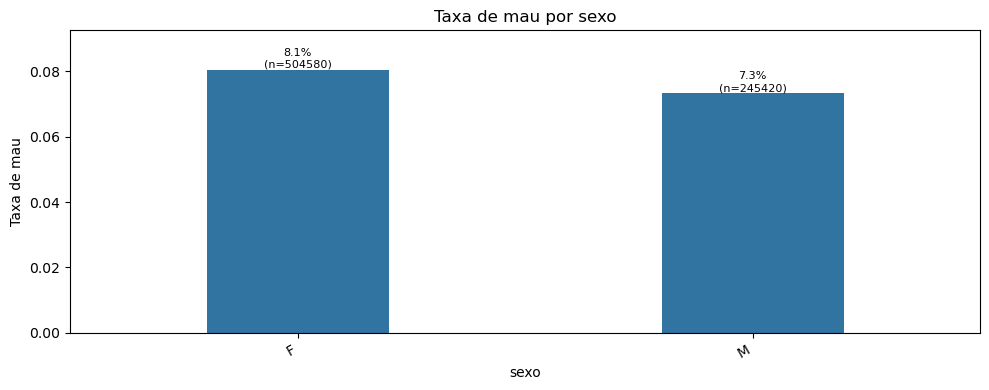

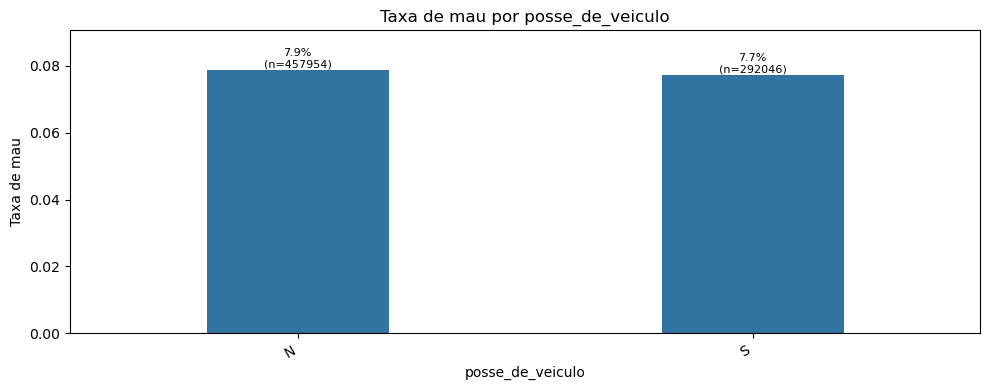

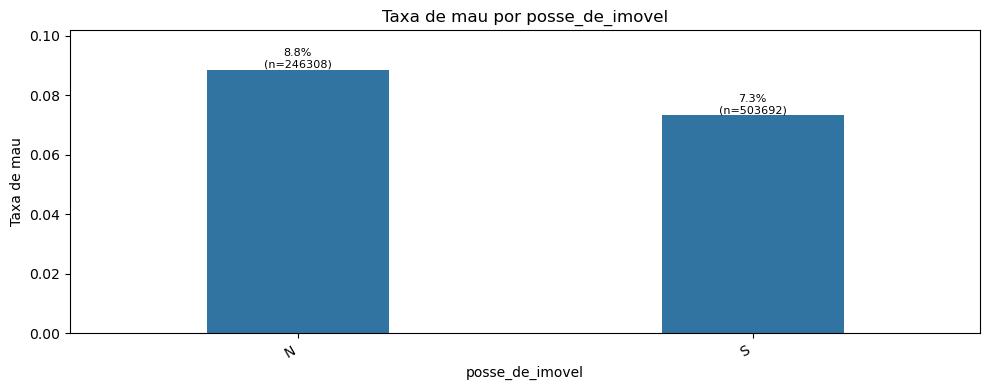

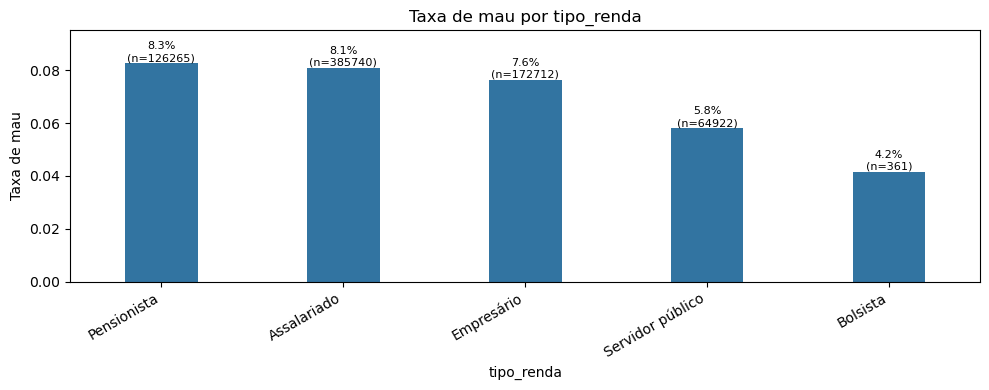

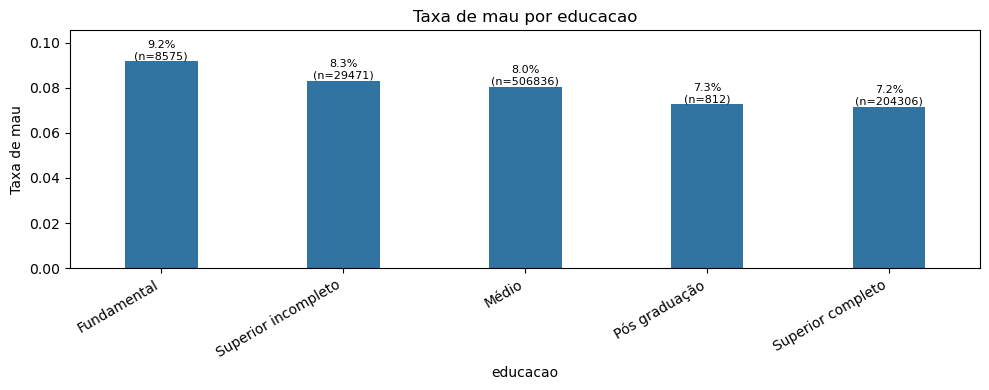

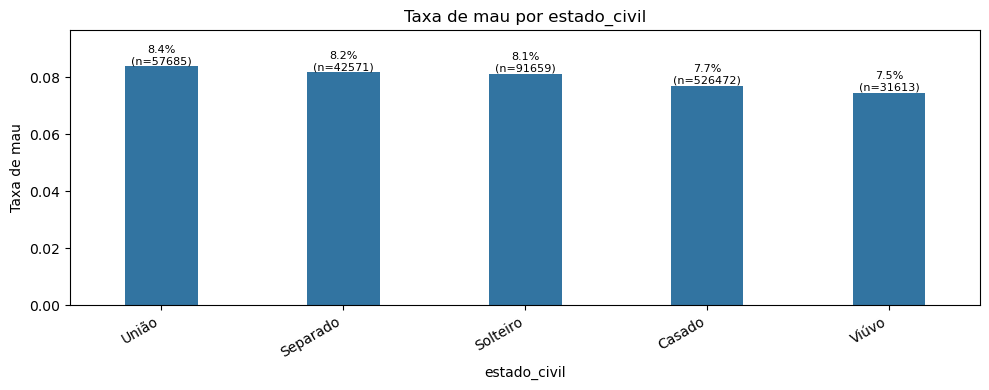

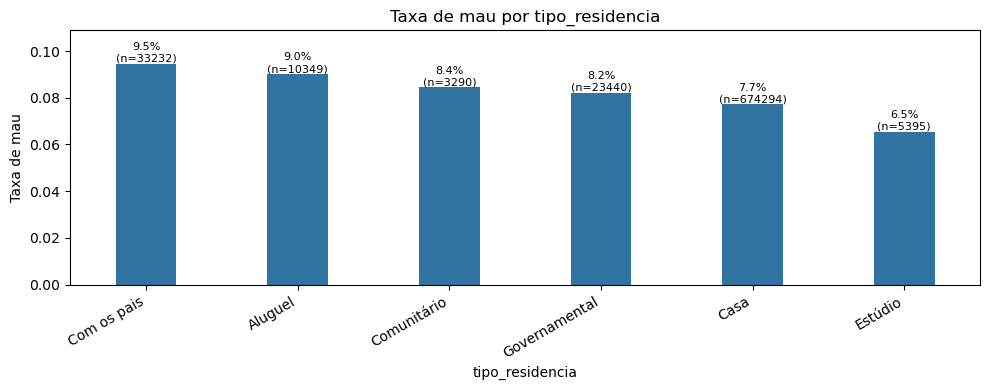

In [28]:
qualitativas = ['sexo', 'posse_de_veiculo', 'posse_de_imovel', 'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']

target = 'mau'

for col in qualitativas:
    tmp = (df
           .groupby(col)[target]
           .agg(qtd='size', taxa_mau='mean')
           .reset_index()
           .sort_values('taxa_mau', ascending=False))

    plt.figure(figsize=(10, 4))
    ax = sns.barplot(data=tmp, x=col, y='taxa_mau',width=0.4)
    plt.title(f"Taxa de mau por {col}")
    plt.ylabel("Taxa de mau")
    plt.xlabel(col)
    plt.xticks(rotation=30, ha='right')
    y_max = tmp['taxa_mau'].max()
    plt.ylim(0, y_max * 1.15)  # 15% de folga acima do máximo


    # rótulo com % e volume
    for i, row in tmp.reset_index(drop=True).iterrows():
        ax.text(i, row['taxa_mau'], f"{row['taxa_mau']*100:.1f}%\n(n={int(row['qtd'])})",
                ha='center', va='bottom', fontsize=8)

    plt.tight_layout()
    plt.show()


<font color="yellow">
A análise bivariada das variáveis qualitativas em relação à taxa de mau indica a existência de algumas pequenas diferenças dentro de cada grupo. Observa-se um risco um pouco maior em perfis associados a menor estabilidade socioeconômica, como menor nível educacional, ausência de imóvel próprio, determinados tipos de residência e categorias específicas de renda. Variáveis como sexo e posse de veículo apresentam diferenças mais sutis, sugerindo baixo poder discriminatório. Os resultados reforçam que essas variáveis contribuem mais como componentes complementares de um modelo do que como fortes discriminadores individuais de inadimplência.
</font>


## Desenvolvimento do modelo

Desenvolva um modelo de *credit scoring* através de uma regressão logística.

- Trate valores missings e outliers
- Trate 'zeros estruturais'
- Faça agrupamentos de categorias conforme vimos em aula
- Proponha uma equação preditiva para 'mau'
- Caso hajam categorias não significantes, justifique

In [29]:
import statsmodels.formula.api as smf
from sklearn.metrics import roc_auc_score

# Configurações iniciais

target = 'mau'

num_cols = [
    'qtd_filhos', 'idade', 'tempo_emprego',
    'qt_pessoas_residencia', 'renda'
]

cat_binarias = [
    'sexo', 'posse_de_veiculo', 'posse_de_imovel'
]

cat_multiclasse = [
    'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia'
]

# Cópias das bases
train = df_treino.copy()
oot   = df_oot.copy()


# 1) Tratamento de missings

# Numéricas: mediana do treino
medianas = {}
for c in num_cols:
    train[c] = pd.to_numeric(train[c], errors='coerce')
    oot[c]   = pd.to_numeric(oot[c], errors='coerce')

    medianas[c] = train[c].median()
    train[c] = train[c].fillna(medianas[c])
    oot[c]   = oot[c].fillna(medianas[c])

# Categóricas: Missing
for c in cat_binarias + cat_multiclasse:
    train[c] = train[c].astype('object').fillna('Missing')
    oot[c]   = oot[c].astype('object').fillna('Missing')


# 2) Tratamento de outliers

def winsorize_series(s, p_low=0.01, p_high=0.99):
    lo, hi = s.quantile([p_low, p_high])
    return s.clip(lo, hi), lo, hi

wins_limits = {}
for c in num_cols:
    train[c], lo, hi = winsorize_series(train[c], 0.01, 0.99)
    wins_limits[c] = (lo, hi)
    oot[c] = oot[c].clip(lo, hi)

# 3) Zeros estruturais

for base in [train, oot]:
    base['tempo_emprego_zero'] = (base['tempo_emprego'] == 0).astype(int)
    base['renda_zero'] = (base['renda'] == 0).astype(int)
    base['log_renda'] = np.log1p(base['renda'])


In [30]:
for col in cat_multiclasse:
    so_treino = sorted(set(train[col].unique()) - set(oot[col].unique()))
    so_oot    = sorted(set(oot[col].unique()) - set(train[col].unique()))

    print(f"\n{col}")
    print("  Só no treino:", so_treino[:20], "..." if len(so_treino) > 20 else "")
    print("  Só no OOT:  ", so_oot[:20], "..." if len(so_oot) > 20 else "")



tipo_renda
  Só no treino: [] 
  Só no OOT:   [] 

educacao
  Só no treino: [] 
  Só no OOT:   [] 

estado_civil
  Só no treino: [] 
  Só no OOT:   [] 

tipo_residencia
  Só no treino: [] 
  Só no OOT:   [] 


In [31]:
cat_multiclasse = ['tipo_renda', 'educacao', 'tipo_residencia']

for col in cat_multiclasse:
    tab = pd.concat([
        train[col].value_counts(dropna=False).rename('qtd_treino'),
        train[col].value_counts(normalize=True, dropna=False).mul(100).round(2).rename('%_treino'),
        oot[col].value_counts(dropna=False).rename('qtd_oot'),
        oot[col].value_counts(normalize=True, dropna=False).mul(100).round(2).rename('%_oot')
    ], axis=1).fillna(0)

    tab['so_treino'] = (tab['qtd_treino'] > 0) & (tab['qtd_oot'] == 0)
    tab['so_oot']    = (tab['qtd_oot'] > 0) & (tab['qtd_treino'] == 0)

    tab = tab.sort_values(['%_treino','%_oot'], ascending=False)

    print(f"\n===== {col} =====")
    display(tab.head(30))



===== tipo_renda =====


,qtd_treino,%_treino,qtd_oot,%_oot,so_treino,so_oot
tipo_renda,,,,,,
Assalariado,308460,51.41,77280,51.52,False,False
Empresário,138141,23.02,34571,23.05,False,False
Pensionista,101127,16.85,25138,16.76,False,False
Servidor público,51981,8.66,12941,8.63,False,False
Bolsista,291,0.05,70,0.05,False,False



===== educacao =====


,qtd_treino,%_treino,qtd_oot,%_oot,so_treino,so_oot
educacao,,,,,,
Médio,405449,67.57,101387,67.59,False,False
Superior completo,163440,27.24,40866,27.24,False,False
Superior incompleto,23559,3.93,5912,3.94,False,False
Fundamental,6901,1.15,1674,1.12,False,False
Pós graduação,651,0.11,161,0.11,False,False



===== tipo_residencia =====


,qtd_treino,%_treino,qtd_oot,%_oot,so_treino,so_oot
tipo_residencia,,,,,,
Casa,539336,89.89,134958,89.97,False,False
Com os pais,26730,4.46,6502,4.33,False,False
Governamental,18742,3.12,4698,3.13,False,False
Aluguel,8262,1.38,2087,1.39,False,False
Estúdio,4296,0.72,1099,0.73,False,False
Comunitário,2634,0.44,656,0.44,False,False


<font color="yellow">
A categoria “Bolsista” apresentou baixa representatividade na base de treino e não estava presente de forma consistente entre as safras. O mesmo ocorreu com os níveis de escolaridade "Fundamental" e "Pós graduação", além dos tipos de residência "Aluguel", "Comunitário" e "Estúdio". Para garantir estabilidade do modelo e evitar problemas de extrapolação no conjunto out of time, essas categorias foram agrupadas como “Outros”.
</font>

In [32]:
# 4) Agrupamento de categorias de menor frequência

def agrupar_com_ref(serie_treino, serie_aplicar, min_pct=0.02):
    freq = serie_treino.value_counts(normalize=True)
    raras = freq[freq < min_pct].index
    return serie_aplicar.where(~serie_aplicar.isin(raras), other='Outros')

for c in cat_multiclasse:
    train[c] = agrupar_com_ref(train[c], train[c], min_pct=0.02)
    oot[c]   = agrupar_com_ref(train[c], oot[c],   min_pct=0.02)

cat_multiclasse = ['tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia']

for col in cat_multiclasse:
    niveis_treino = set(train[col].dropna().unique())
    
    # qualquer nível do OOT que não exista no treino vira "Outros"
    oot[col] = oot[col].where(oot[col].isin(niveis_treino), other='Outros')


# 5) get_dummies SOMENTE para binárias

train_dum = pd.get_dummies(
    train,
    columns=cat_binarias,
    drop_first=True
)

oot_dum = pd.get_dummies(
    oot,
    columns=cat_binarias,
    drop_first=True
)

# Alinhar colunas treino x OOT
train_dum, oot_dum = train_dum.align(
    oot_dum, join='left', axis=1, fill_value=0
)

# 6) Garantir target binário 0/1

train_dum[target] = train_dum[target].astype(int)
oot_dum[target]   = oot_dum[target].astype(int)

# Colunas numéricas/dummies com variância zero (constantes)
cols_constantes = [c for c in train_dum.columns if c != 'mau' and train_dum[c].nunique(dropna=False) <= 1]

train_dum = train_dum.drop(columns=cols_constantes, errors='ignore')
oot_dum   = oot_dum.drop(columns=cols_constantes, errors='ignore')


# 7) Regressão logística (Logit)

formula = """
mau ~ idade + tempo_emprego + qt_pessoas_residencia + qtd_filhos
      + log_renda +
      + sexo_M + posse_de_veiculo_S + posse_de_imovel_S
      + C(tipo_renda) + C(educacao) + C(estado_civil) + C(tipo_residencia)
"""

modelo_logit = smf.logit(formula=formula, data=train_dum).fit(disp=False)
print(modelo_logit.summary())


# 8) Diagnóstico de significância

nao_significantes = modelo_logit.pvalues[modelo_logit.pvalues > 0.05].sort_values()
print("\nTermos NÃO significantes (p > 0.05):")
print(nao_significantes)



                           Logit Regression Results                           
Dep. Variable:                    mau   No. Observations:               600000
Model:                          Logit   Df Residuals:                   599977
Method:                           MLE   Df Model:                           22
Date:                sex, 09 jan 2026   Pseudo R-squ.:                  0.1272
Time:                        12:10:13   Log-Likelihood:            -1.2040e+05
converged:                       True   LL-Null:                   -1.3794e+05
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Intercept                               6.2845      0.179     35.029      0.000       5.933       6.636
sexo_M[T.True]                         -0.0160      0.01

## Avaliação do modelo

Avalie o poder discriminante do modelo pelo menos avaliando acurácia, KS e Gini.

Avalie estas métricas nas bases de desenvolvimento e *out of time*.

In [33]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

target = "mau"

# Função KS (ranking)
def ks_stat(y_true, y_score):
    tmp = pd.DataFrame({"y": y_true, "score": y_score}).dropna().sort_values("score")
    tmp["cum_bad"]  = (tmp["y"] == 1).cumsum() / (tmp["y"] == 1).sum()
    tmp["cum_good"] = (tmp["y"] == 0).cumsum() / (tmp["y"] == 0).sum()
    return float((tmp["cum_bad"] - tmp["cum_good"]).abs().max())

# Faixa de aceitação ótima (KS máximo por corte)
def find_best_acceptance_threshold_by_ks(y_true, y_score):
    tmp = pd.DataFrame({"y": y_true, "score": y_score}).dropna()
    thresholds = np.sort(tmp["score"].unique())

    best_th, best_ks = None, -np.inf
    for th in thresholds:
        y_pred = (tmp["score"] >= th).astype(int)

        tp = ((y_pred == 1) & (tmp["y"] == 1)).sum()
        fn = ((y_pred == 0) & (tmp["y"] == 1)).sum()
        fp = ((y_pred == 1) & (tmp["y"] == 0)).sum()
        tn = ((y_pred == 0) & (tmp["y"] == 0)).sum()

        tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        ks_cut = abs(tpr - fpr)

        if ks_cut > best_ks:
            best_ks = ks_cut
            best_th = th

    return float(best_th), float(best_ks)

# Scores do modelo
train_dum['score'] = modelo_logit.predict(train_dum)
oot_dum['score']   = modelo_logit.predict(oot_dum)

# Métricas de ranking
auc_dev = roc_auc_score(train_dum[target], train_dum['score'])
auc_oot = roc_auc_score(oot_dum[target],   oot_dum['score'])

gini_dev = 2 * auc_dev - 1
gini_oot = 2 * auc_oot - 1

ks_dev = ks_stat(train_dum[target], train_dum['score'])
ks_oot = ks_stat(oot_dum[target],   oot_dum['score'])

# Faixa de aceitação ótima
faixa_aceitacao_otima, ks_cut_dev = find_best_acceptance_threshold_by_ks(
    train_dum[target], train_dum['score']
)

resultado_ranking = pd.DataFrame({
    "Base": ["Desenvolvimento", "OOT"],
    "AUC": [auc_dev, auc_oot],
    "Gini": [gini_dev, gini_oot],
    "KS": [ks_dev, ks_oot],
})

print("Métricas de ranking:")
print(resultado_ranking.to_string(index=False, float_format="%.4f"))

print(f"\nFaixa de aceitação ótima: {faixa_aceitacao_otima:.4f}")




Métricas de ranking:
           Base    AUC   Gini     KS
Desenvolvimento 0.7702 0.5403 0.3985
            OOT 0.7377 0.4753 0.3464

Faixa de aceitação ótima: 0.0621


<font color="yellow">
Os resultados indicam que o modelo apresenta poder discriminante moderado, com AUC de 0,77, Gini de 0,54 e KS de 0,40 na base de desenvolvimento. Na base out of time, observa-se uma redução dessas métricas (AUC = 0,74, Gini = 0,48 e KS = 0,35), o que é esperado devido a mudanças temporais no perfil da população e confirma ausência de overfitting severo. A manutenção de um KS relativamente elevado no OOT sugere que o modelo preserva capacidade de ordenação de risco ao longo do tempo.

A faixa de aceitação ótima estimada no desenvolvimento (≈ 6,2%) representa o ponto de corte que maximiza a separação estatística entre bons e maus pagadores (KS máximo), mas não deve ser interpretada como uma regra de decisão final. Esse resultado reforça que o modelo atua principalmente como um instrumento de ordenação de risco, enquanto a definição do ponto de corte adequado deve ser realizada pelo negócio, considerando objetivos de aprovação, apetite a risco e contexto econômico.
</font>
